In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

PROJECT_PATH = "/content/drive/MyDrive/Adversarial-Multimodal-AI-Framework"

os.makedirs(PROJECT_PATH, exist_ok=True)

print("Project folder created successfully.")
print(PROJECT_PATH)

Project folder created successfully.
/content/drive/MyDrive/Adversarial-Multimodal-AI-Framework


In [4]:
!pip install timm opencv-python transformers

In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"divyanshrawat7","key":"86467c7d4b9beb65bb529c57e57afccb"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:26<00:00, 152MB/s]



In [8]:
!unzip -q 140k-real-and-fake-faces.zip

In [9]:
import os

for root, dirs, files in os.walk('/content'):
    if 'train' in root.lower():
        print(root)

/content/real_vs_fake/real-vs-fake/train
/content/real_vs_fake/real-vs-fake/train/real
/content/real_vs_fake/real-vs-fake/train/fake


In [10]:
import os

for root, dirs, files in os.walk('/content'):
    if 'real_vs_fake' in root.lower():
        print(root)

/content/real_vs_fake
/content/real_vs_fake/real-vs-fake
/content/real_vs_fake/real-vs-fake/train
/content/real_vs_fake/real-vs-fake/train/real
/content/real_vs_fake/real-vs-fake/train/fake
/content/real_vs_fake/real-vs-fake/valid
/content/real_vs_fake/real-vs-fake/valid/real
/content/real_vs_fake/real-vs-fake/valid/fake
/content/real_vs_fake/real-vs-fake/test
/content/real_vs_fake/real-vs-fake/test/real
/content/real_vs_fake/real-vs-fake/test/fake


In [11]:
import os

for root, dirs, files in os.walk('/content'):
    if len(files) > 0:
        print(root)

/content
/content/.config
/content/.config/configurations
/content/.config/logs/2026.05.12
/content/drive/.shortcut-targets-by-id/1MG7CLEjIgLPMqOBO6qVg4jyP_CXqX2Hh/Company Wise DSA Questions
/content/drive/MyDrive
/content/drive/MyDrive/Divefire
/content/drive/MyDrive/Classroom/B.Tech A (1)
/content/drive/MyDrive/Classroom/Environment Science A
/content/drive/MyDrive/Classroom/Engineering Chemistry A
/content/drive/MyDrive/Classroom/TCS 201 & PCS 251 Section A
/content/drive/MyDrive/Classroom/B.TECH A
/content/drive/MyDrive/1918335_miniproject
/content/drive/MyDrive/TEAM 4 FINAL SUBMISSION_2-1.zip (Unzipped Files)/TEAM 4 FINAL SUBMISSION
/content/drive/MyDrive/Kali LINUX
/content/drive/MyDrive/7668962069_Graphic Era Hill University
/content/drive/MyDrive/Certificates
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Time-Series-Analysis-with-Non-Linear-Models-for-Energy-Consumption-Forecasting-main
/content/drive/MyDrive/Time-Series-Analysis-with-Non-Linear-Models-for-Energ

In [12]:
from glob import glob

real_images = glob('/content/real_vs_fake/real-vs-fake/train/real/*.jpg')

fake_images = glob('/content/real_vs_fake/real-vs-fake/train/fake/*.jpg')

print(f"Real Images: {len(real_images)}")
print(f"Fake Images: {len(fake_images)}")

Real Images: 50000
Fake Images: 50000


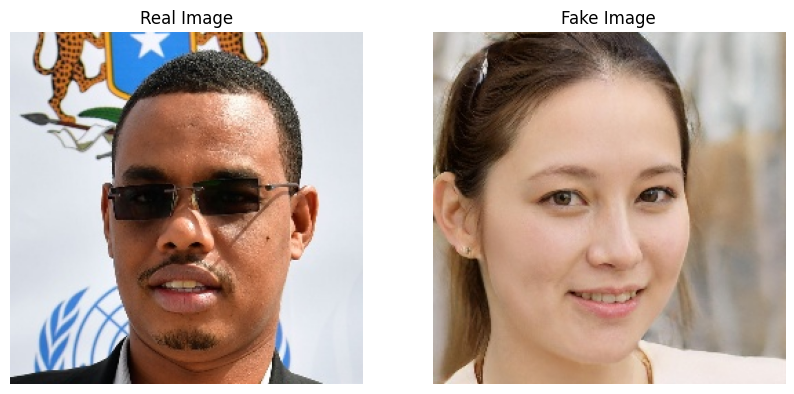

In [13]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_real = random.choice(real_images)
sample_fake = random.choice(fake_images)

real_img = Image.open(sample_real)
fake_img = Image.open(sample_fake)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(real_img)
plt.title("Real Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(fake_img)
plt.title("Fake Image")
plt.axis('off')

plt.show()

In [14]:
DATASET_PATH = "/content/real_vs_fake"

print("Dataset path saved successfully.")
print(DATASET_PATH)

Dataset path saved successfully.
/content/real_vs_fake


In [15]:
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

valid_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    "/content/real_vs_fake/real-vs-fake/train",
    transform=train_transforms
)

valid_dataset = datasets.ImageFolder(
    "/content/real_vs_fake/real-vs-fake/valid",
    transform=valid_transforms
)

print("Training Samples:", len(train_dataset))
print("Validation Samples:", len(valid_dataset))

print("Classes:", train_dataset.classes)

Training Samples: 100000
Validation Samples: 20000
Classes: ['fake', 'real']


In [46]:
from torch.utils.data import DataLoader, Subset
import random

train_indices = random.sample(
    range(len(train_dataset)),
    5000
)

valid_indices = random.sample(
    range(len(valid_dataset)),
    1000
)

train_subset = Subset(
    train_dataset,
    train_indices
)

valid_subset = Subset(
    valid_dataset,
    valid_indices
)

train_loader = DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_subset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Randomized DataLoaders created successfully.")

Randomized DataLoaders created successfully.


In [47]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [48]:
import torch
import torch.nn as nn
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

model = timm.create_model(
    'efficientnet_b0',
    pretrained=True,
    num_classes=2
)

model = model.to(device)

print("EfficientNet-B0 loaded successfully.")

Using Device: cuda
EfficientNet-B0 loaded successfully.


In [49]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Loss function and optimizer initialized.")

Loss function and optimizer initialized.


In [50]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [51]:
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader)

    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [52]:
num_epochs = 5

train_losses = []
valid_losses = []

train_accuracies = []
valid_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    valid_loss, valid_acc = validate(
        model,
        valid_loader,
        criterion
    )

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Validation Loss: {valid_loss:.4f}")
    print(f"Validation Accuracy: {valid_acc:.4f}")

    print("-" * 50)

Epoch 1/5
Train Loss: 0.9297
Train Accuracy: 0.7664
Validation Loss: 0.6005
Validation Accuracy: 0.8410
--------------------------------------------------
Epoch 2/5
Train Loss: 0.1503
Train Accuracy: 0.9468
Validation Loss: 0.4551
Validation Accuracy: 0.8770
--------------------------------------------------
Epoch 3/5
Train Loss: 0.0832
Train Accuracy: 0.9730
Validation Loss: 0.4496
Validation Accuracy: 0.8800
--------------------------------------------------
Epoch 4/5
Train Loss: 0.0458
Train Accuracy: 0.9836
Validation Loss: 0.3807
Validation Accuracy: 0.9110
--------------------------------------------------
Epoch 5/5
Train Loss: 0.0402
Train Accuracy: 0.9902
Validation Loss: 0.3233
Validation Accuracy: 0.9140
--------------------------------------------------


In [53]:
import os

os.makedirs('/content/models', exist_ok=True)

MODEL_PATH = '/content/models/fake_profile_detector.pth'

torch.save(model.state_dict(), MODEL_PATH)

print("Model saved successfully.")
print(MODEL_PATH)

Model saved successfully.
/content/models/fake_profile_detector.pth


In [54]:
class_names = train_dataset.classes

sample_image, sample_label = valid_dataset[0]

model.eval()

with torch.no_grad():

    image = sample_image.unsqueeze(0).to(device)

    outputs = model(image)

    probabilities = torch.softmax(outputs, dim=1)

    confidence, prediction = torch.max(probabilities, 1)

predicted_class = class_names[prediction.item()]

print("Predicted Class:", predicted_class)

print("Confidence:", confidence.item() * 100)

Predicted Class: fake
Confidence: 90.79310297966003


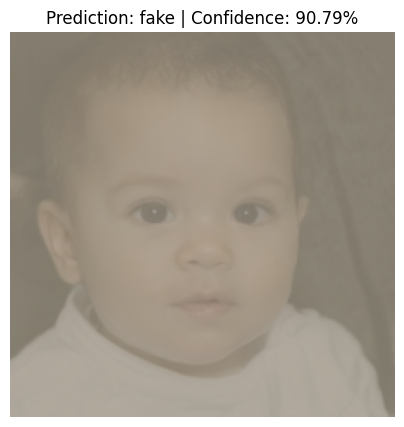

In [55]:
import matplotlib.pyplot as plt
import numpy as np

display_image = sample_image.clone()

display_image = display_image.permute(1, 2, 0).cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

display_image = (display_image * std) + mean

display_image = np.clip(display_image, 0, 1)

plt.figure(figsize=(5,5))

plt.imshow(display_image)

plt.title(
    f"Prediction: {predicted_class} | Confidence: {confidence.item()*100:.2f}%"
)

plt.axis("off")

plt.show()

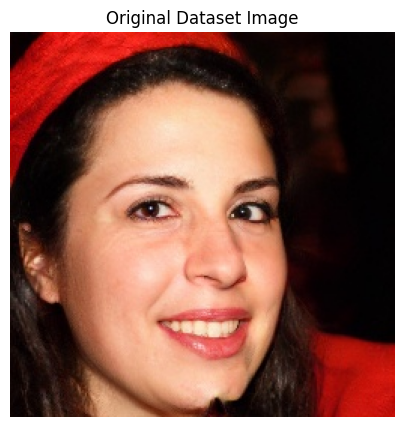

In [56]:
from PIL import Image
import matplotlib.pyplot as plt

real_path = train_dataset.samples[0][0]

original_image = Image.open(real_path)

plt.figure(figsize=(5,5))

plt.imshow(original_image)

plt.title("Original Dataset Image")

plt.axis("off")

plt.show()

In [57]:
from PIL import Image

def predict_image(image_path):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(image_tensor)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, prediction = torch.max(probabilities, 1)

    class_names = train_dataset.classes

    predicted_class = class_names[prediction.item()]

    confidence_score = confidence.item() * 100

    return predicted_class, confidence_score

In [58]:
from google.colab import files

uploaded = files.upload()

Saving Untitled design.png to Untitled design (1).png


In [59]:
uploaded_image_path = list(uploaded.keys())[0]

prediction, confidence = predict_image(uploaded_image_path)

print("Prediction:", prediction)

print(f"Confidence: {confidence:.2f}%")

Prediction: fake
Confidence: 100.00%
